In [1]:
# imports
import pandas as pd
from sklearn.decomposition import PCA, SparsePCA, IncrementalPCA
from sklearn.model_selection import train_test_split
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch import optim
import torch
import torch.nn as nn
from biom import load_table
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from TRPCA import trpca
from tqdm import tqdm 

In [2]:
table = load_table('data/oral_2550.biom').to_dataframe(dense=True).T.astype(int)
taxonomy_table = pd.read_csv('data/oral_taxonomy.txt', sep='\t', index_col=0)
age_metadata = pd.read_csv('data/oral_2550_map.txt', sep='\t', index_col=0, dtype={'qiita_host_age': float})

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_66775/446224930.py:3: DtypeWarning: Columns (87,280,391,626,660,661,760,761,763,764,765,766,767,768,769,806,809,933) have mixed types. Specify dtype option on import or set low_memory=False.
  age_metadata = pd.read_csv('data/oral_2550_map.txt', sep='\t', index_col=0)


### Save these as designated files for simplicity...

In [3]:
from TRPCA import utils
columns_to_drop = table.columns[table.apply(lambda col: (col != 0).sum()) < 0]# drop columns with low prev
df1 = table.drop(columns=columns_to_drop)
df1 = np.log(df1+1)
print('CLR Transformed.')

CLR Transformed.


In [4]:
df1 = df1.loc[age_metadata.index]

In [5]:
n_dimensions = 256
# # # # # # Preprocess with PCA (Re-using the PCA application code from earlier)
X1_reduced, pca1 = utils.apply_pca(df1, n_dimensions) 
df = pd.DataFrame(X1_reduced, index=df1.index)

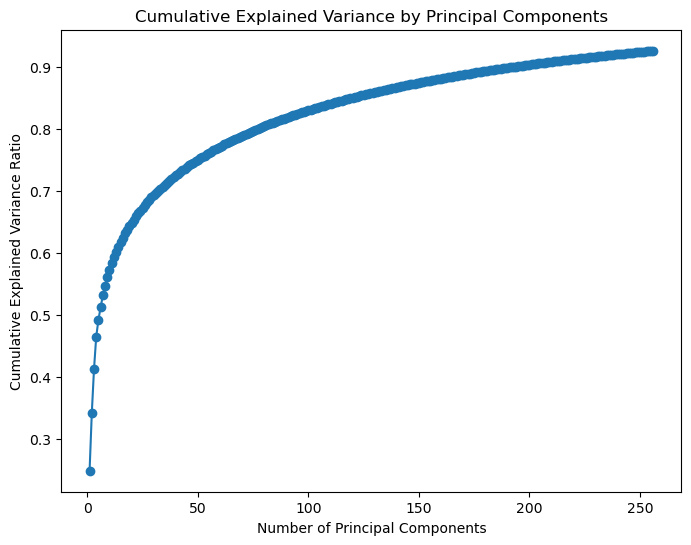

In [6]:
import numpy as np
import matplotlib.pyplot as plt

cum_explained_variance_ratio = np.cumsum(pca1.explained_variance_ratio_)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained_variance_ratio) + 1), cum_explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

In [7]:
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].qiita_host_age
df = df.loc[df.age.notna()]

In [8]:
age_metadata = age_metadata.loc[df.index]

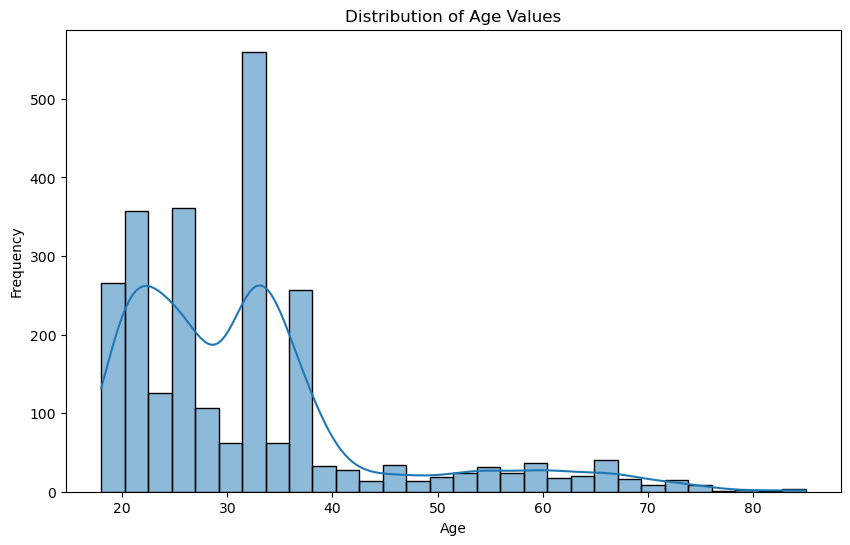

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of age values using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age Values')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from TRPCA import trpca

y = df.age.astype(float)

X_pca_tensor = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X_pca_tensor, y, test_size=0.2, random_state=42)

# Standardizing the data
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

# Converting to PyTorch tensors
train_features = torch.tensor(X_train_scaled, dtype=torch.float32)
test_features = torch.tensor(X_test_scaled, dtype=torch.float32)
train_targets = torch.tensor(y_train.iloc[:].values, dtype=torch.float32).unsqueeze(1)
test_targets = torch.tensor(y_test.iloc[:].values, dtype=torch.float32).unsqueeze(1)

# Creating DataLoader instances
train_dataset = TensorDataset(train_features, train_targets)
test_dataset = TensorDataset(test_features, test_targets)

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

regression_model = trpca.TransformerRegressionModel(feature_size=n_dimensions, num_transformer_layers=3, nhead=8, dim_feedforward=2048, dropout=0.2, fast_transformer=True)

# Calculate the number of parameters
total_params = sum(p.numel() for p in regression_model.parameters())
trainable_params = sum(p.numel() for p in regression_model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")

Total Parameters: 5787649
Trainable Parameters: 5787649


/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [11]:
# Loss function and optimizer
criterion = nn.L1Loss()
optimizer = torch.optim.SGD(regression_model.parameters(), lr=9e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0, last_epoch=-1)

epochs = 5000
best_valid_loss = float('inf')  # Initialize the best validation loss
train_losses = []
valid_losses = []

In [12]:
import torch
import gc
torch.mps.empty_cache()
gc.collect()

204

In [13]:
pbar = tqdm(total=epochs, desc="Training Progress")
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
for epoch in range(epochs):
    regression_model.to(device)
    regression_model.train()
    train_loss = 0
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        outputs = regression_model(batch_features)
        loss = criterion(outputs['regression_output'], batch_labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_features.size(0)
    
    # Average train loss for the epoch
    train_loss_epoch = train_loss / len(train_loader.dataset)
    train_losses.append(train_loss_epoch)
    
    # Validation phase
    regression_model.eval()
    valid_loss = 0
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = regression_model(batch_features)
            loss = criterion(outputs['regression_output'], batch_labels)
            valid_loss += loss.item() * batch_features.size(0)
    
    # Average valid loss for the epoch
    valid_loss_epoch = valid_loss / len(test_loader.dataset)
    valid_losses.append(valid_loss_epoch)

    scheduler.step()
    # Update the progress bar
    pbar.update(1)
    pbar.set_postfix({
        'Epoch': epoch + 1,
        'Train Loss': f'{train_loss_epoch:.4f}',
        'Validation Loss': f'{valid_loss_epoch:.4f}'
    })
    
    # Check for best validation loss
    if valid_loss_epoch < best_valid_loss:
        best_valid_loss = valid_loss_epoch
        # Save the model
        torch.save(regression_model.state_dict(), 'model_checkpoints/best_16s_oral_age_regression_model.pth')

# Close the progress bar after all epochs are done
pbar.close()

Training Progress: 100%|██████████| 5000/5000 [06:17<00:00, 13.25it/s, Epoch=5000, Train Loss=0.4107, Validation Loss=4.7300]


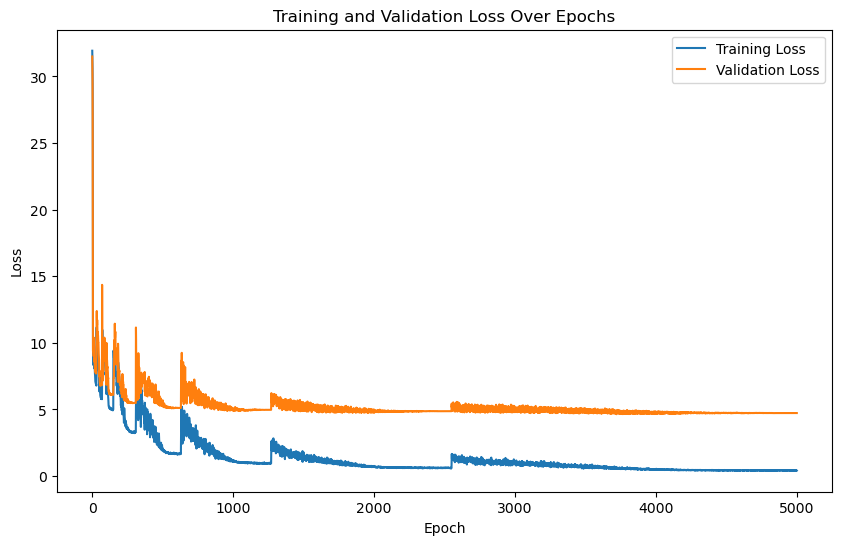

In [14]:
regression_model.load_state_dict(torch.load('model_checkpoints/best_16s_oral_age_regression_model.pth'))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

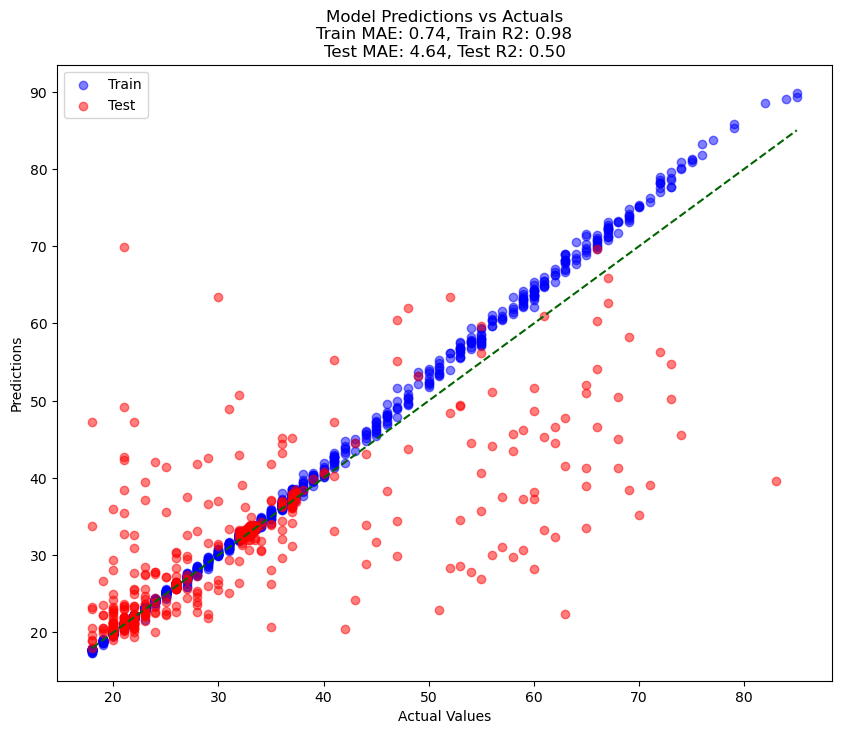

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# After training, evaluate the model on both the training and testing sets
regression_model.eval()  # Set the model to evaluation mode

# Collect predictions and actual values for the training set
train_preds, train_actuals = [], []
for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    batch_preds = regression_model(batch_features)['regression_output'].detach()
    train_preds.extend(batch_preds.view(-1).tolist())
    train_actuals.extend(batch_labels.view(-1).tolist())

# Collect predictions and actual values for the test set
test_preds, test_actuals = [], []
for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    batch_preds = regression_model(batch_features)['regression_output'].detach()
    test_preds.extend(batch_preds.view(-1).tolist())
    test_actuals.extend(batch_labels.view(-1).tolist())

train_mae = mean_absolute_error(train_actuals, train_preds)
test_mae = mean_absolute_error(test_actuals, test_preds)
train_r2 = r2_score(train_actuals, train_preds)
test_r2 = r2_score(test_actuals, test_preds)


# Plotting
plt.figure(figsize=(10, 8))

# Train predictions vs actuals
plt.scatter(train_actuals, train_preds, color='blue', alpha=0.5, label='Train')
# Test predictions vs actuals
plt.scatter(test_actuals, test_preds, color='red', alpha=0.5, label='Test')

# Perfect predictions line
plt.plot([min(train_actuals+test_actuals), max(train_actuals+test_actuals)], 
         [min(train_actuals+test_actuals), max(train_actuals+test_actuals)], 
         color='darkgreen', linestyle='--')

plt.title(f'Model Predictions vs Actuals\nTrain MAE: {train_mae:.2f}, Train R2: {train_r2:.2f}\nTest MAE: {test_mae:.2f}, Test R2: {test_r2:.2f}')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.legend()
plt.show()

### feature extraction

In [16]:
import torch
import numpy as np
import shap

def model_wrapper(x):
    # Convert the input array to a PyTorch tensor, ensuring it's of type float32
    x_tensor = torch.tensor(x, dtype=torch.float32, device=device)  # Also move tensor to the appropriate device in one step

    # Forward pass through the model with a batch of data
    with torch.no_grad():  # Ensure no gradients are computed to save memory and computations
        model_output = regression_model(x_tensor)
    
    # Assuming the output is a dictionary, extract the relevant part and convert to numpy
    return model_output['regression_output'].detach().cpu().numpy()

# Set the device appropriately
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
regression_model = regression_model.to(device)

# Create an explainer with the model wrapper
explainer = shap.Explainer(model_wrapper, X_train_scaled)

In [17]:
shap_values = explainer(X_test_scaled, max_evals=2*n_dimensions+1)

PermutationExplainer explainer: 511it [03:02,  2.71it/s]                         


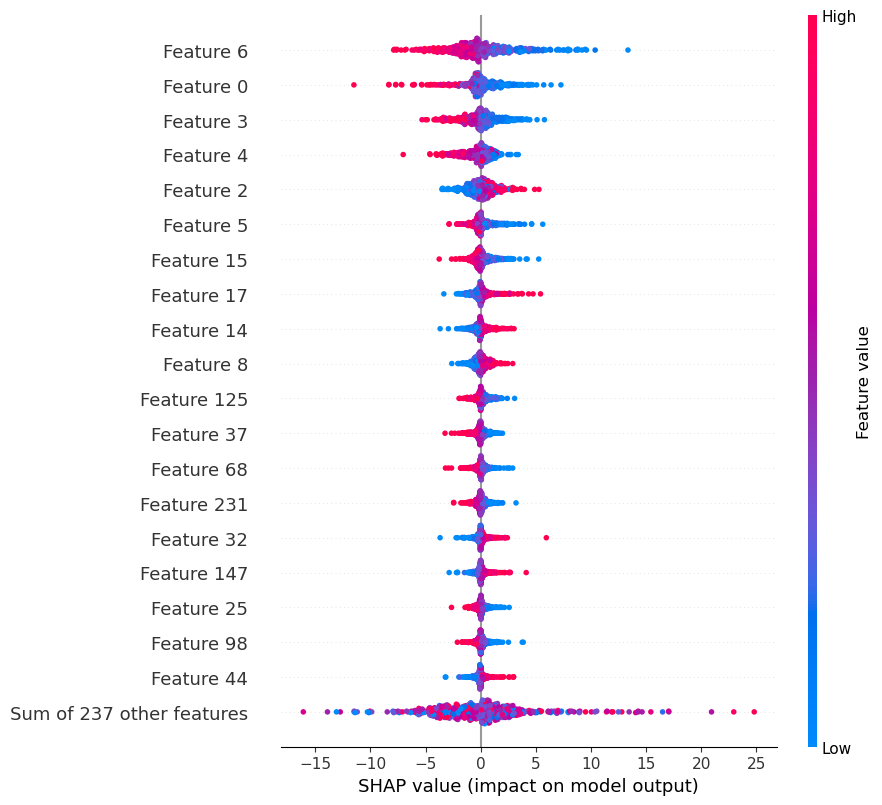

In [18]:
shap.plots.beeswarm(shap_values, order=shap_values.abs.mean(0), max_display=20)

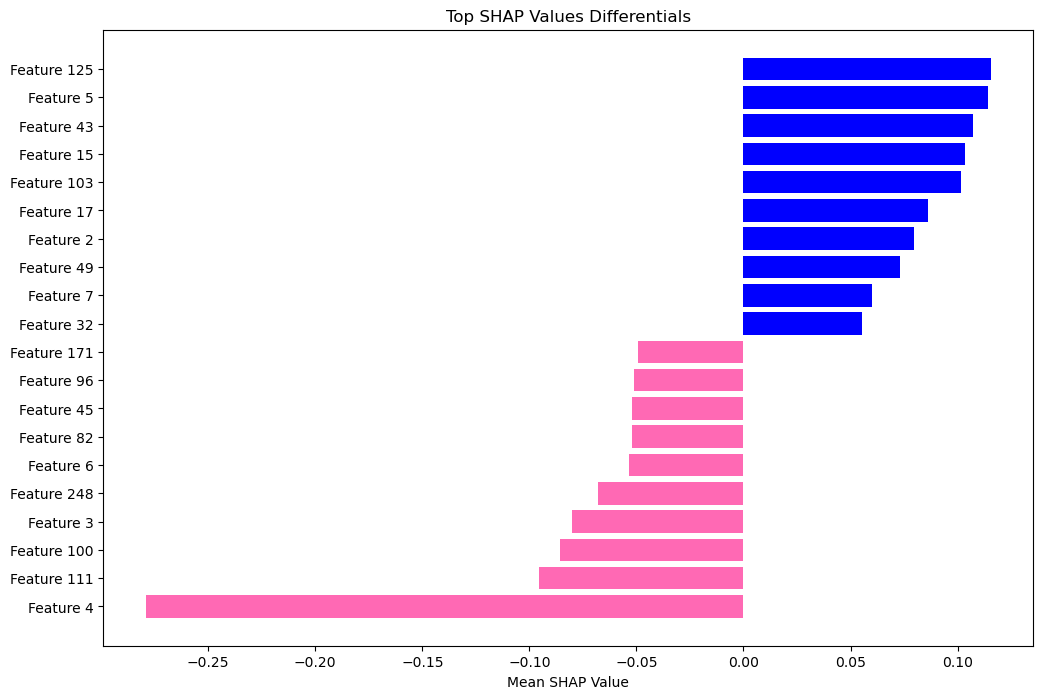

In [19]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Assuming shap_values is your SHAP values Explanation object
mean_shap_values = np.mean(shap_values.values, axis=0)

# Sort the SHAP values
sorted_indices = np.argsort(mean_shap_values)

# Get top 10 positive and top 10 negative features
top_10_positive_indices = sorted_indices[-10:]
top_10_negative_indices = sorted_indices[:10]

# Combine and sort them to plot
top_indices = np.concatenate([top_10_negative_indices, top_10_positive_indices])
top_indices_sorted = top_indices[np.argsort(mean_shap_values[top_indices])]

# Get the SHAP values for the top features
top_features = mean_shap_values[top_indices_sorted]
feature_names = np.array(shap_values.feature_names)[top_indices_sorted]

# Create the bar plot
plt.figure(figsize=(12, 8))
plt.barh(feature_names, top_features, color=np.where(top_features > 0, 'blue', '#FF69B4'))
plt.xlabel('Mean SHAP Value')
plt.title('Top SHAP Values Differentials')
plt.show()


In [20]:
# Assuming:
# shap_values - SHAP values from your SHAP explainer, specific to the principal components
# pca_components - The components matrix from PCA, typically accessed via pca.components_

# Calculate the importance of each original feature
original_feature_importance = np.dot(shap_values.values, pca1.components_)

# Now, original_feature_importance contains the propagated SHAP values for each original feature.
# To get a summarized importance across all samples:
mean_abs_importance = np.mean(np.abs(original_feature_importance), axis=0)
mean_importance = np.mean(original_feature_importance, axis=0)
# To rank features by importance:
feature_ranking = np.argsort(-mean_abs_importance)  # Negate for descending order

feature_names = df1.columns  # Replace with actual feature names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Absolute Importance': mean_abs_importance,
    'Mean Importance': mean_importance,
})

importance_df = importance_df.iloc[feature_ranking]  # Sorted by importance

In [21]:
importance_df.head(10)

,Feature,Mean Absolute Importance,Mean Importance
6215,TACGTAGGTGGCAAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAG...,0.738950,-0.095658
22196,TACGTAGGTCCCGAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAG...,0.636299,0.008782
13969,TACGGAGGGTGCGAGCGTTAATCGGAATAACTGGGCGTAAAGGGCA...,0.634613,0.001898
11551,TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGTG...,0.560922,-0.008745
20083,TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGAG...,0.554735,0.020878
12914,TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGCG...,0.529686,-0.051056
26089,TACGTAGGGCGCGAGCGTTGTCCGGAATTATTGGGCGTAAAGAGCT...,0.478659,-0.096816
24098,TACGTAGGGTGCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGAG...,0.475034,-0.013629
487,TACGGAAGGTCCGGGCGTTATCCGGATTTATTGGGTTTAAAGGGAG...,0.474542,0.121301
7552,TACGTAGGTCCCGAGCGTTATCCGGATTTATTGGGCGTAAAGCGAG...,0.467540,0.023363


In [23]:
taxonomy_table

,Taxon,Confidence
Feature ID,,
TACGGAGGATGCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGTGGCGTATTAAGTCAGTGGTGAAAAGCTGCAGCTCAACTGTAGTCTTG,k__Bacteria; p__Bacteroidetes; c__Bacteroidia;...,0.998840
TACGGAAGGTTCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCTGGAGATTAAGTGTGTTGTGAAATGTAGACGCTCAACGTCTGACTTG,k__Bacteria; p__Bacteroidetes; c__Bacteroidia;...,0.999971
TACAGAGGGTGCGAGCGTTAATCGGGTTTACTGGGCGTAAAGCGTGCGTAGGCGGCTTTATAAGTTGGATGTGAAATCCCCGAGCTTAACTTGGGAATTG,k__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.799599
TACGTAGGGTACTAGCGTTGTCCGGTTTTATTGGGCGTAAAGGGCTTGTAGGTGGTTTGTCGCGTCTGTCGTGAAATCCCATGGCTTAACTGTGGGCTTG,k__Bacteria; p__Actinobacteria; c__Actinobacte...,0.998825
TACGTAGGGTGCGAGCGTTGTCCGGAATTATTGGGCGTATAGGGCTTGTAGGCGGTTTGTTAGGTCGGGAGTTAAATCCGGGGGCTCAACCCCCGTTCGC,k__Bacteria; p__Actinobacteria; c__Actinobacte...,0.911152
...,...,...
TCCGACGGTTGCCCGCGTTCCTCGGCATTCCTGGTCTTACCGCGTGCTTCGGTGGTGATTTAAGTCCGTTGTGAAAGCCCTGGGCTCAACCTGGGAATTG,k__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.870976
TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCCGTTTGATAAGCGTGCTGTGTAATATAGTGGCTCAACCTCTATCGTG,k__Bacteria; p__Bacteroidetes; c__Bacteroidia;...,1.000000
TACGTAGGGGGCGAGCGTTGTCCGGAATTACTGGGCGTAAAGGGTTCGCAGGCGGCATGGCAAGTCCGATGTAAAAGGCGAAGGCTCAACCTTCATAAGC,k__Bacteria; p__Firmicutes; c__Clostridia; o__...,0.999778


In [24]:
taxon_dict = dict(zip(taxonomy_table.index, taxonomy_table['Taxon']))

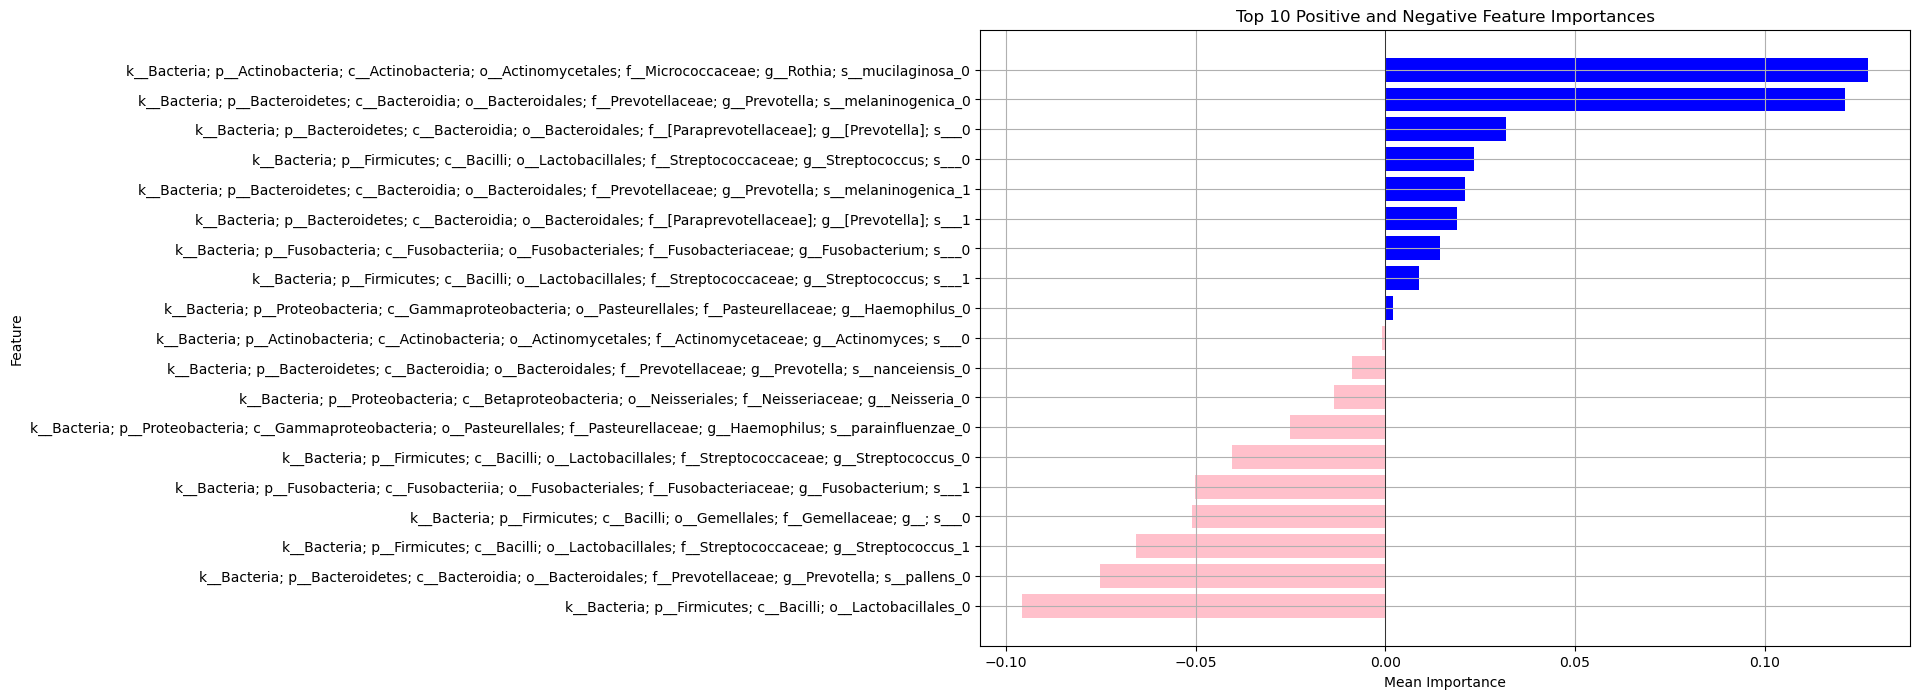

In [25]:
# Sort the DataFrame by 'Mean Absolute Importance' in descending order
importance_df_sorted = importance_df.sort_values(by='Mean Absolute Importance', ascending=False)

# Extract the top features after sorting by 'Mean Absolute Importance'
top_features = importance_df_sorted.head(20)  # Considering a larger number to then filter by Mean Importance

# Separate the top positive and top negative Mean Importance values
top_positive = top_features[top_features['Mean Importance'] > 0].sort_values(by='Mean Importance', ascending=False).head(10)
top_negative = top_features[top_features['Mean Importance'] < 0].sort_values(by='Mean Importance', ascending=False).head(10)

# Combine top positive and negative features
combined_df = pd.concat([top_positive, top_negative])
combined_df['Feature'] = combined_df['Feature'].map(taxon_dict)

# Add unique suffixes to feature names to differentiate them
feature_count = {}
unique_features = []
for feature in combined_df['Feature']:
    if feature in feature_count:
        feature_count[feature] += 1
        unique_feature = f"{feature}_{feature_count[feature]}"
    else:
        feature_count[feature] = 0
        unique_feature = f"{feature}_{feature_count[feature]}"
    unique_features.append(unique_feature)

combined_df['Unique Feature'] = unique_features

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(combined_df['Unique Feature'], combined_df['Mean Importance'], color=['blue' if x >= 0 else 'pink' for x in combined_df['Mean Importance']])
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.title('Top 10 Positive and Negative Feature Importances')
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()  # To have the top positive values on the top
plt.grid(True)
plt.show()


In [26]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Define the number of top features to consider
n_top_features = 100  # Set this to your desired number of top features

# Assuming 'importance_df' contains the features ranked by importance
top_features = importance_df['Feature'][:n_top_features]

X_np = table[top_features].loc[table.index.isin(age_metadata.index)]
y_np = age_metadata.loc[age_metadata.index.isin(table.index), 'qiita_host_age']

# Initialize a list to store the correlation results along with sample counts and p-values
correlation_results = []

# Calculate correlation for each top feature
for feature in top_features:
    # Drop rows where the feature value is 0 or less to avoid errors in log transformation
    valid_indices = X_np[X_np[feature] > 3].index
    log_feature = np.log(X_np.loc[valid_indices, feature])
    valid_y_np = y_np.loc[valid_indices]
    
    # Calculate the Pearson correlation and p-value
    if len(valid_indices) > 1:  # Ensure there are enough samples to compute correlation
        correlation, p_value = pearsonr(log_feature, valid_y_np)
        # Store the result along with the number of samples used
        correlation_results.append({
            'Feature': feature,
            'Correlation with Age': correlation,
            'P-value': p_value,
            'Number of Samples': len(valid_indices)
        })
    else:
        # If not enough data points, store as NaN or handle accordingly
        correlation_results.append({
            'Feature': feature,
            'Correlation with Age': np.nan,
            'P-value': np.nan,
            'Number of Samples': len(valid_indices)
        })

# Convert the results list to a DataFrame for better visualization
correlation_df = pd.DataFrame(correlation_results)

/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [27]:
# Filter to find statistically significant correlations (p-value <= 0.05)
significant_correlations = correlation_df[correlation_df['P-value'] <= 0.05]

# Sort by the absolute value of the correlation strength, descending
significant_correlations_sorted = significant_correlations.copy()
significant_correlations_sorted['Abs Correlation'] = significant_correlations_sorted['Correlation with Age'].abs()
significant_correlations_sorted = significant_correlations_sorted.sort_values(by='Abs Correlation', ascending=False)


In [28]:
# Add the Taxon column to the first DataFrame
significant_correlations_sorted['Taxon'] = significant_correlations_sorted['Feature'].map(taxon_dict)

In [29]:
def get_valid_taxon(taxon_string):
    # Split the string by ';'
    parts = taxon_string.split(';')
    
    # Iterate backwards through the list
    for part in reversed(parts):
        # Check if the substring after '__' is non-empty
        if '__' in part and len(part.split('__')[1]) > 0:
            return part
    # If no valid part is found, return an empty string or handle it as needed
    return ""

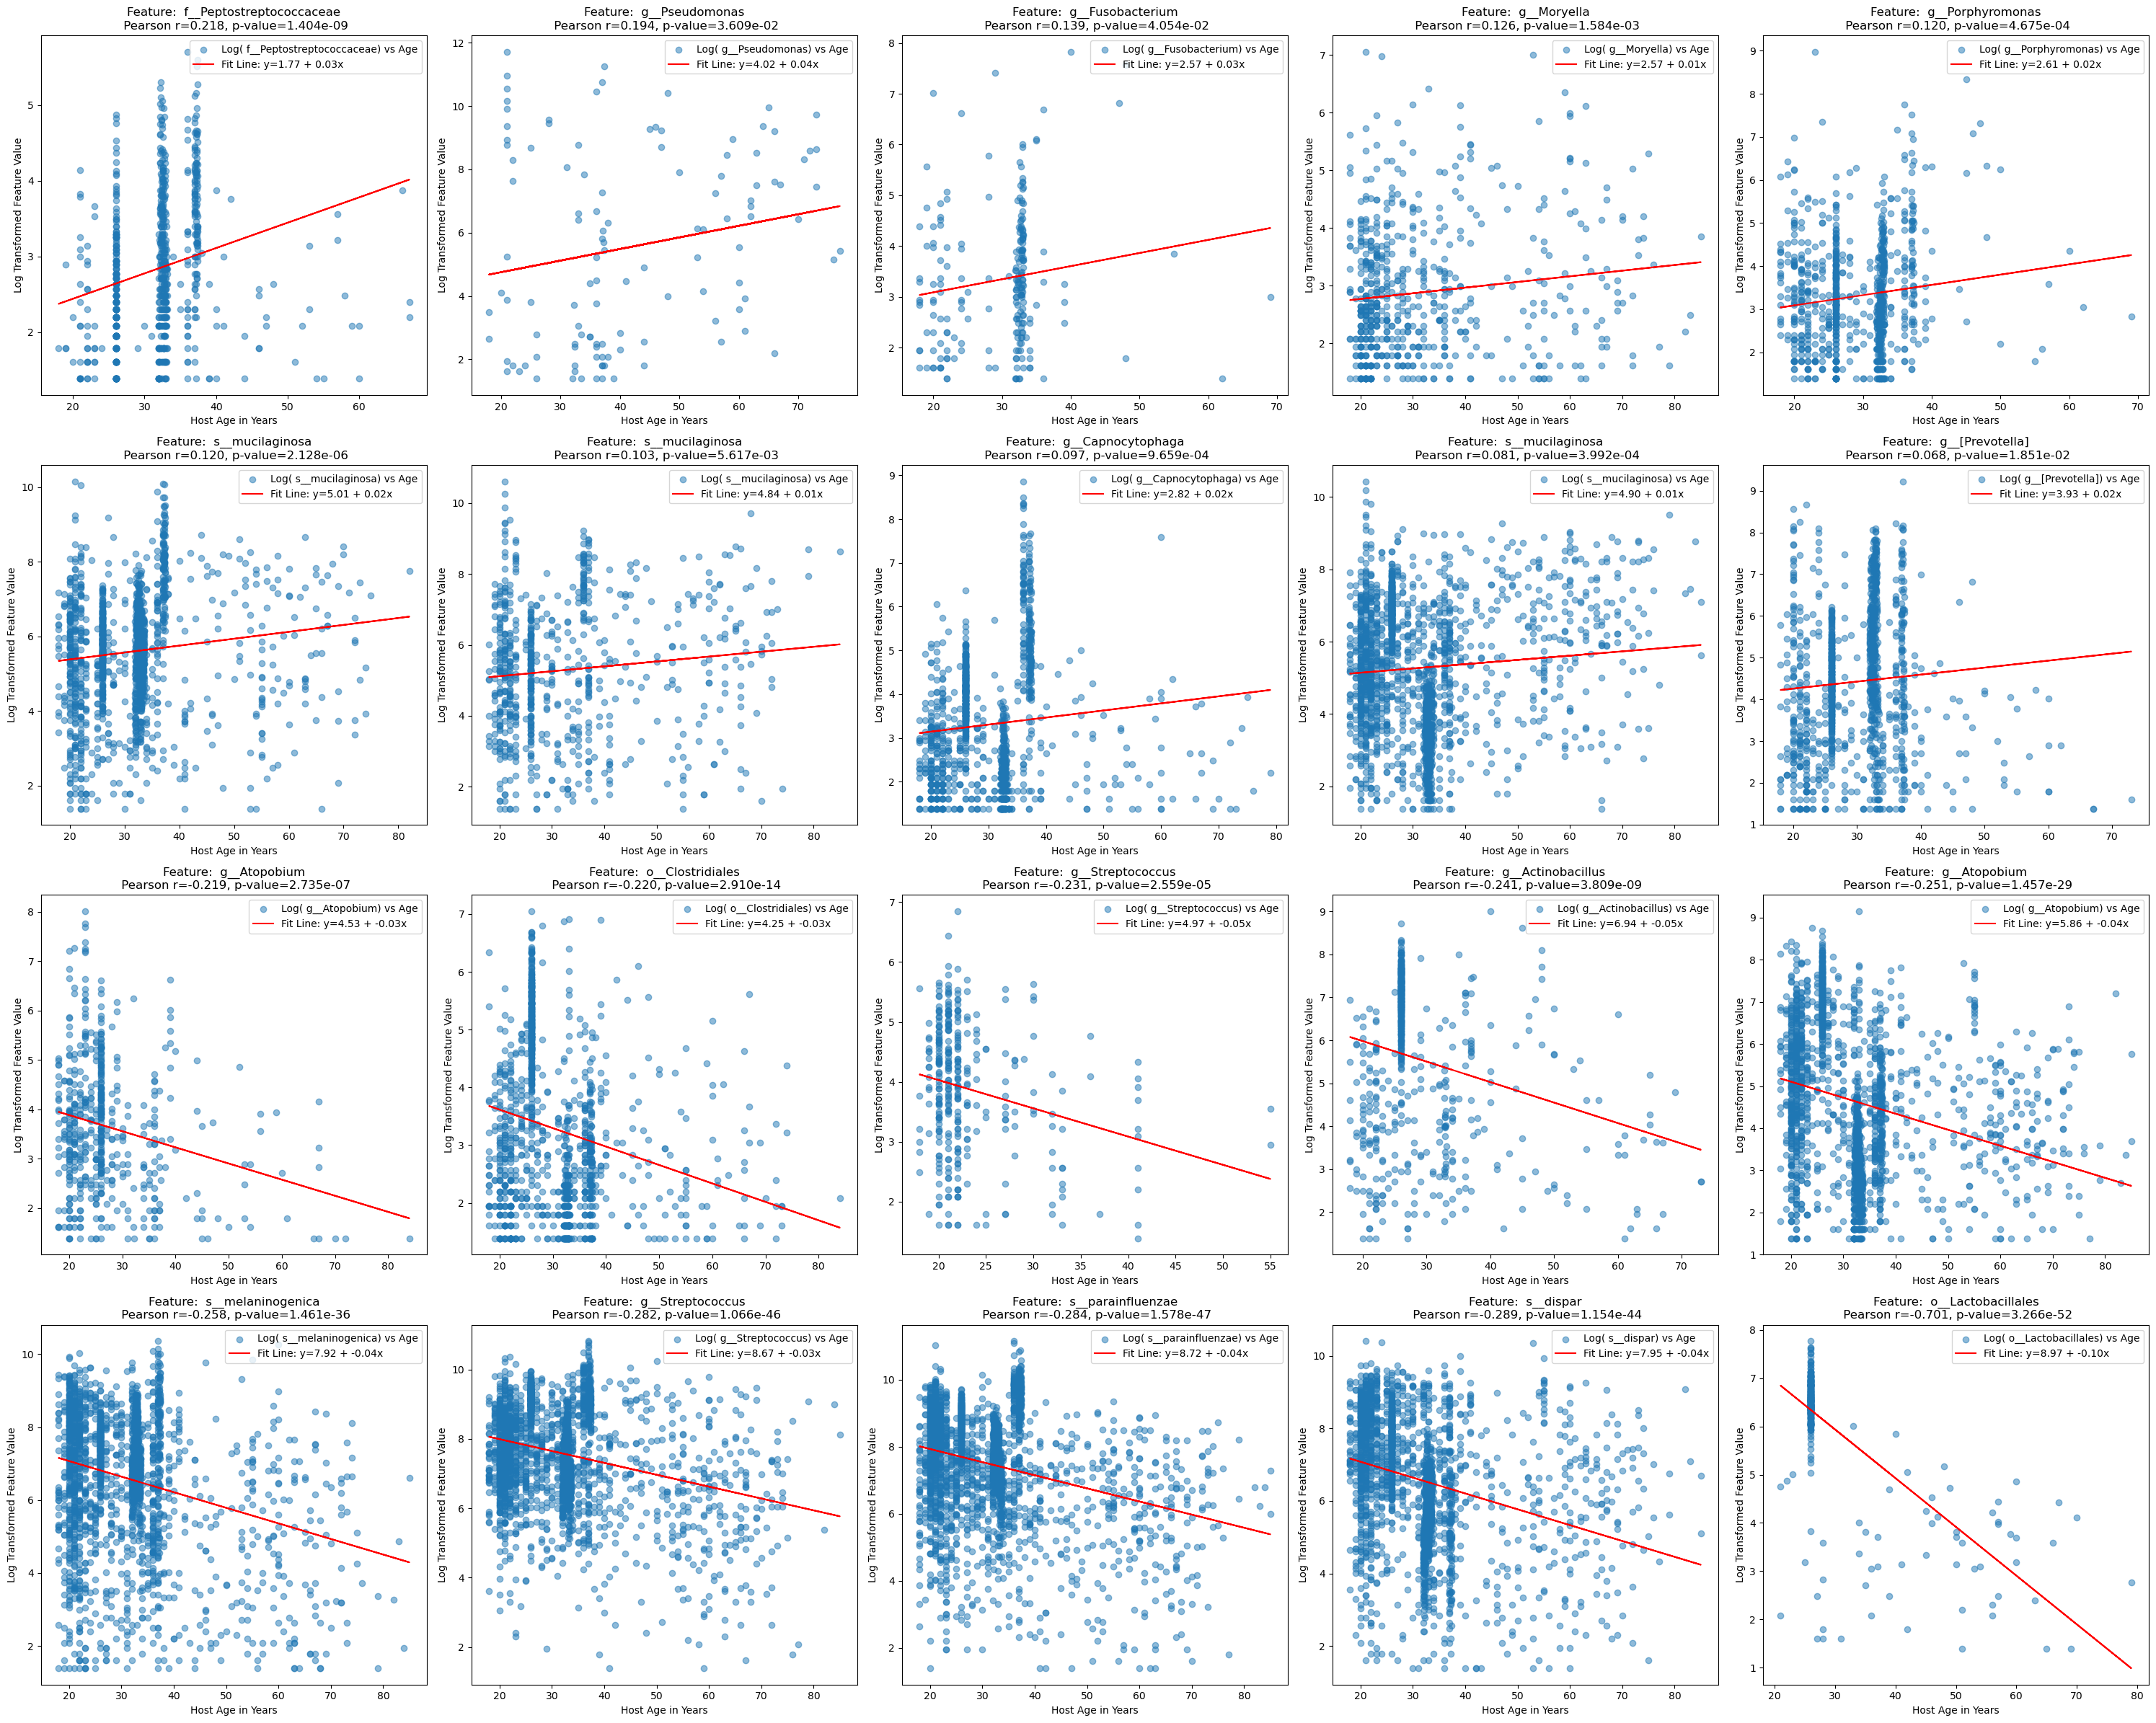

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Assuming significant_correlations_sorted is already defined as a DataFrame
# Sort by 'Correlation with Age'
significant_correlations_sorted = significant_correlations_sorted.sort_values(by='Correlation with Age', ascending=False)

# Extract top 10 positive and top 10 negative correlations
top_positive = significant_correlations_sorted.head(10)
top_negative = significant_correlations_sorted.tail(10)

# Combine the top 10 positive and top 10 negative features
top_features = pd.concat([top_positive, top_negative])

# Filter the data
X_np = table[top_features['Feature']].loc[table.index.isin(age_metadata.index)]
y_np = age_metadata.loc[age_metadata.index.isin(X_np.index)].qiita_host_age
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(30, 24))  # Adjusted for 4 rows and 5 columns

axes = axes.flatten()  # Flatten the axes array for easy indexing

for idx, (feature, taxon) in enumerate(zip(top_features['Feature'], top_features['Taxon'])):
    valid_indices = X_np[X_np[feature] > 3].index
    log_feature = np.log(X_np.loc[valid_indices, feature])
    valid_y_np = y_np.loc[valid_indices]
    
    # Calculate Pearson correlation and fit a linear model for the line of best fit
    if len(log_feature) > 1:
        r_value, p_value = pearsonr(valid_y_np, log_feature)
        slope, intercept = np.polyfit(valid_y_np, log_feature, 1)

        taxon_string = significant_correlations_sorted.loc[significant_correlations_sorted["Feature"] == feature]["Taxon"].iloc[0]
        valid_taxon = get_valid_taxon(taxon_string)

        # Plotting
        axes[idx].scatter(valid_y_np, log_feature, alpha=0.5, label=f'Log({valid_taxon}) vs Age')
        # Add line of best fit
        axes[idx].plot(valid_y_np, intercept + slope * valid_y_np, 'r-', label=f'Fit Line: y={intercept:.2f} + {slope:.2f}x')
        axes[idx].set_title(f'Feature: {valid_taxon}\n Pearson r={r_value:.3f}, p-value={p_value:.3e}')
    else:
        axes[idx].text(0.5, 0.5, 'Not enough data', horizontalalignment='center', verticalalignment='center', transform=axes[idx].transAxes)
    
    axes[idx].set_ylabel('Log Transformed Feature Value')
    axes[idx].set_xlabel('Host Age in Years')
    axes[idx].legend()

plt.tight_layout()
plt.show()


/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = ge

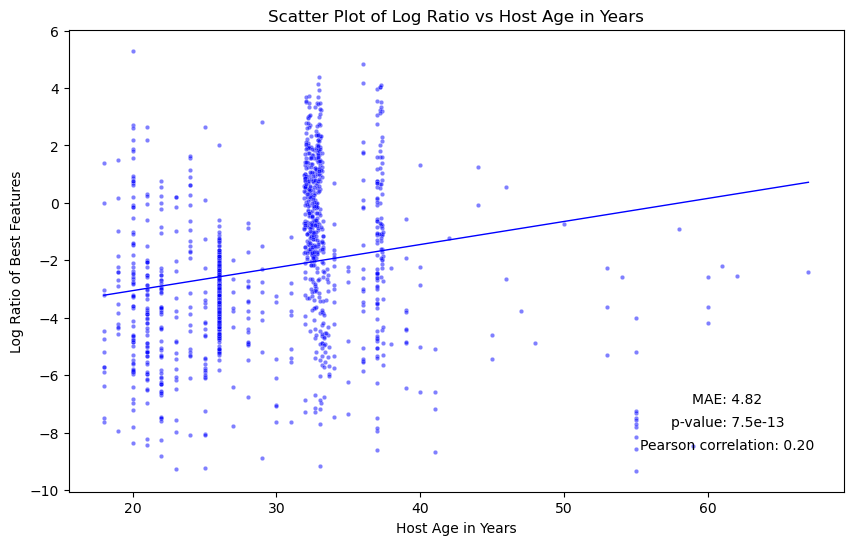

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
import itertools

# Sort by absolute correlation
significant_correlations_sorted = significant_correlations_sorted.sort_values(by='Abs Correlation', ascending=False)
top_positive = significant_correlations_sorted.loc[significant_correlations_sorted['Number of Samples']>500].sort_values(by='Correlation with Age', ascending=False).head(20)

# Sort by "Correlation with Age" to get the top negative correlations
top_negative = significant_correlations_sorted.loc[significant_correlations_sorted['Number of Samples']>500].sort_values(by='Correlation with Age', ascending=True).head(20)

# Combine the two DataFrames
combined_df = pd.concat([top_positive, top_negative])

numerator_features = top_positive['Feature'].tolist()
denominator_features = top_negative['Feature'].tolist()

# Initialize best correlation and MAE
best_correlation = -np.inf
best_mae = np.inf
best_combination = None
best_n = -np.inf

# List to store results
results = []

# Function to plot and calculate correlation and MAE
def calculate_metrics(numerator_features, denominator_features, age_metadata):
    numerator_sum = table[numerator_features].sum(axis=1)
    denominator_sum = table[denominator_features].sum(axis=1)
    log_ratio_df = pd.DataFrame()
    log_ratio_df['log_ratio'] = np.log(numerator_sum / denominator_sum)
    log_ratio_df['age'] = age_metadata['qiita_host_age']
    log_ratio_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    log_ratio_df.dropna(inplace=True)
    
    correlation, p_value = pearsonr(log_ratio_df['log_ratio'], log_ratio_df['age'])
    X = log_ratio_df['log_ratio'].values.reshape(-1, 1)
    y = log_ratio_df['age'].values
    best_fit_line = np.poly1d(np.polyfit(log_ratio_df['log_ratio'], log_ratio_df['age'], 1))
    mae = mean_absolute_error(y, best_fit_line(log_ratio_df['log_ratio']))
    n = len(y)
    return correlation, mae, p_value, n

# Define the maximum number of features to consider for each side
max_numerator_features = 1
max_denominator_features = 1

# Generate combinations
for num_numerator in range(1, max_numerator_features + 1):
    for num_denominator in range(1, max_denominator_features + 1):
        # Get combinations of the specified sizes
        numerator_combinations = list(itertools.combinations(numerator_features, num_numerator))
        denominator_combinations = list(itertools.combinations(denominator_features, num_denominator))
        
        for numerator_comb in numerator_combinations:
            for denominator_comb in denominator_combinations:
                try:
                    correlation, mae, p_value, n = calculate_metrics(list(numerator_comb), list(denominator_comb), age_metadata)
                    results.append({
                        'Numerator Features': list(numerator_comb),
                        'Denominator Features': list(denominator_comb),
                        'Correlation': correlation,
                        'MAE': mae,
                        'P-value': p_value,
                        'Number_features': len(numerator_comb) + len(denominator_comb),
                        'n': n,
                    })
                    
                    if mae < best_mae and p_value<0.05 and n>1200:
                        best_correlation = correlation
                        best_mae = mae
                        best_p_value = p_value
                        best_combination = (list(numerator_comb), list(denominator_comb))
                        best_n = n
                except Exception as e:
                    print(e)
                    # pass

results_df = pd.DataFrame(results)

# Plot the best combination
best_numerator_features, best_denominator_features = best_combination
numerator_sum = table[best_numerator_features].sum(axis=1)
denominator_sum = table[best_denominator_features].sum(axis=1)
log_ratio_df = pd.DataFrame()
log_ratio_df['log_ratio'] = np.log(numerator_sum / denominator_sum)
log_ratio_df['age'] = age_metadata['qiita_host_age']
log_ratio_df.replace([np.inf, -np.inf], np.nan, inplace=True)
log_ratio_df.dropna(inplace=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=log_ratio_df, x='age', y='log_ratio', color='blue', alpha=0.5, s=10)
x_values = np.linspace(log_ratio_df['age'].min(), log_ratio_df['age'].max(), 500)
best_fit_line = np.poly1d(np.polyfit(log_ratio_df['age'], log_ratio_df['log_ratio'], 1))
y_values = best_fit_line(x_values)
plt.plot(x_values, y_values, color='blue', linewidth=1)
plt.ylabel('Log Ratio of Best Features')
plt.xlabel('Host Age in Years')
plt.title('Scatter Plot of Log Ratio vs Host Age in Years')

plt.text(0.85, 0.1, f'Pearson correlation: {best_correlation:.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
plt.text(0.85, 0.15, f'p-value: {best_p_value:.2g}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
plt.text(0.85, 0.2, f'MAE: {best_mae:.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

plt.show()

In [77]:
best_n, best_combination

(1259,
 (['TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGATTGTTAAGTCAGCGGTTAAAGGGTGTGGCTCAACCATACATTGC'],
  ['TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGCGCGCAGGCGGATTGGTCAGTCTGTCTTAAAAGTTCGGGGCTTAACCCCGTGATGG']))

In [78]:
all_sequences = [seq for sublist in best_combination for seq in sublist]
taxonomy_table[taxonomy_table.index.isin(all_sequences)]['Taxon'].values

array(['k__Bacteria; p__Bacteroidetes; c__Bacteroidia; o__Bacteroidales; f__[Paraprevotellaceae]; g__[Prevotella]; s__',
       'k__Bacteria; p__Firmicutes; c__Clostridia; o__Clostridiales; f__Veillonellaceae; g__Veillonella; s__dispar'],
      dtype=object)

In [79]:
results_df.loc[(results_df['P-value']<0.05)&(results_df['MAE']<5)].sort_values(by='n', ascending=False).head(10)

,Numerator Features,Denominator Features,Correlation,MAE,P-value,Number_features,n
140,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGC...,0.200235,4.822569,7.472896e-13,2,1259
148,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGTAGGGGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGT...,0.180924,4.822511,4.409687e-10,2,1172
215,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGGGC...,0.216698,4.770200,1.467396e-13,2,1138
144,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGTAGGGGGCAAGCGTTATCCGGATTCATTGGGCGTAAAGCGC...,0.196332,4.594472,2.843800e-11,2,1129
168,[TACGTATGTCGCGAGCGTTATCCGGAATTATTGGGCATAAAGGGC...,[TACGTAGGGGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGT...,0.253066,4.887175,1.610138e-17,2,1099
164,[TACGTATGTCGCGAGCGTTATCCGGAATTATTGGGCATAAAGGGC...,[TACGTAGGGGGCAAGCGTTATCCGGATTCATTGGGCGTAAAGCGC...,0.262677,4.873053,3.860227e-18,2,1057
209,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGTAGGGTGCAAGCGTTGTCCGGATTTACTGGGCGTAAAGAGC...,0.167401,4.933323,4.647362e-08,2,1053
146,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACATATGGGGCGAGCGTTATCCGGATTTATTGGGTGTAAAGGGT...,0.216155,4.769730,1.712984e-12,2,1043
356,[TACGTAGGGCGCGAGCGTTGTCCGGAATTATTGGGCGTAAAGGGC...,[TACGTAGGGTGCGAGCGTTGTCCGGAATTACTGGGCGTAAAGAGC...,0.258537,4.292044,1.844564e-16,2,982
66,[TACGTAGGGCGCGAGCGTTGTCCGGAATTATTGGGCGTAAAGAGC...,[TACATATGGGGCGAGCGTTATCCGGATTTATTGGGTGTAAAGGGT...,0.277680,4.965363,2.474987e-18,2,953


In [80]:
results_df.sort_values(by='MAE').head(10)

,Numerator Features,Denominator Features,Correlation,MAE,P-value,Number_features,n
18,[TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGCGTAAAGGGT...,[TACGGAGGGTGCGAGCGTTAATCGGAATAACTGGGCGTAAAGGGC...,0.210415,2.006786,7.756601e-04,2,252
13,[TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGCGTAAAGGGT...,[TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGC...,0.213677,2.161599,1.282555e-01,2,52
16,[TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGCGTAAAGGGT...,[TACGTAGGGTGCGAGCGTTGTCCGGAATTACTGGGCGTAAAGAGC...,0.567348,2.182803,1.460414e-46,2,531
113,[TACGGAGGATGCGAGCGTTATCCGGAATCATTGGGTTTAAAGGGT...,[TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGC...,-0.028743,2.241369,6.773244e-01,2,212
5,[TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGCGTAAAGGGT...,[TACGGGGGGTGCGAGCGTTAATCGGAATAACTGGGCGTAAAGGGC...,0.430237,2.453557,8.341538e-16,2,319
9,[TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGCGTAAAGGGT...,[TACGTAGGGTGCAAGCGTTGTCCGGATTTACTGGGCGTAAAGAGC...,0.552358,2.732194,2.754656e-56,2,689
53,[TACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGT...,[TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGC...,0.060044,2.860229,5.238359e-01,2,115
15,[TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGCGTAAAGGGT...,[TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGGGC...,0.396421,2.976133,1.120221e-20,2,511
158,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGGAGGGTGCGAGCGTTAATCGGAATAACTGGGCGTAAAGGGC...,-0.026481,3.102199,5.566816e-01,2,495
385,[TACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGA...,[TACGGGGGGTGCGAGCGTTAATCGGAATAACTGGGCGTAAAGGGC...,-0.075659,3.213334,1.074079e-01,2,454
